,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

stat deskriptif:
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.677083      72.389323      29.089844  141.753906   
std 

C:\Users\LEGION\AppData\Local\Temp\ipykernel_30636\3429627504.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outcome', palette='Set2')


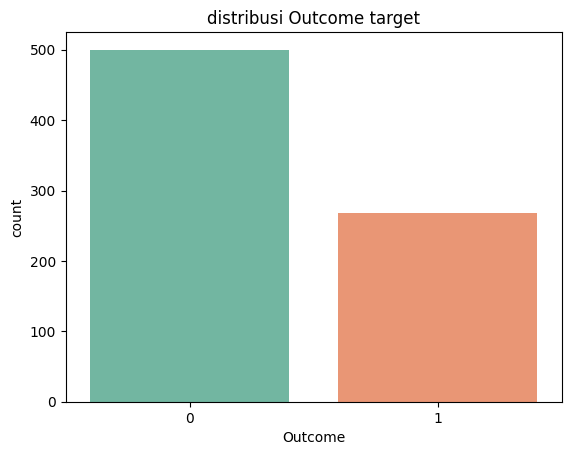

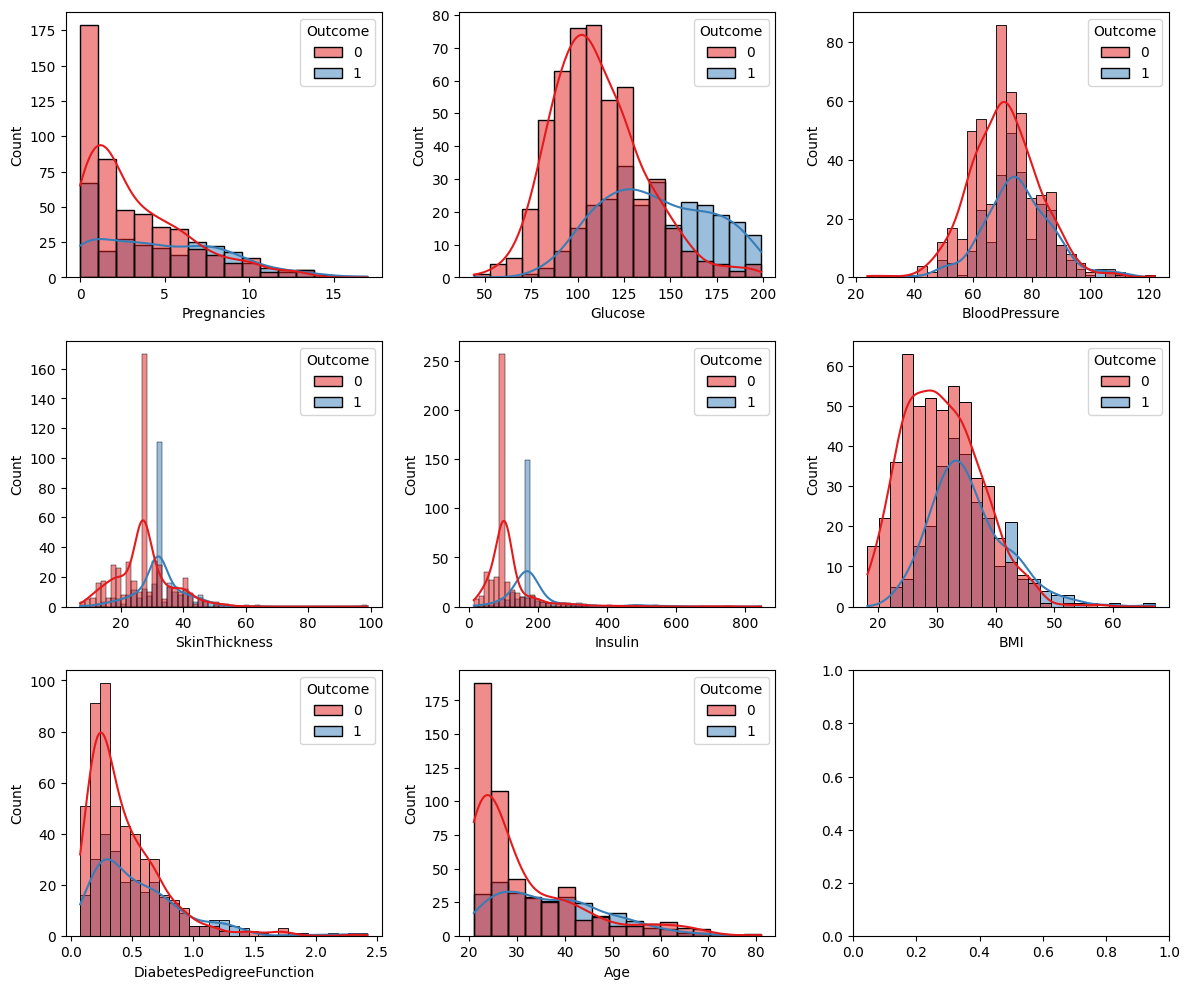

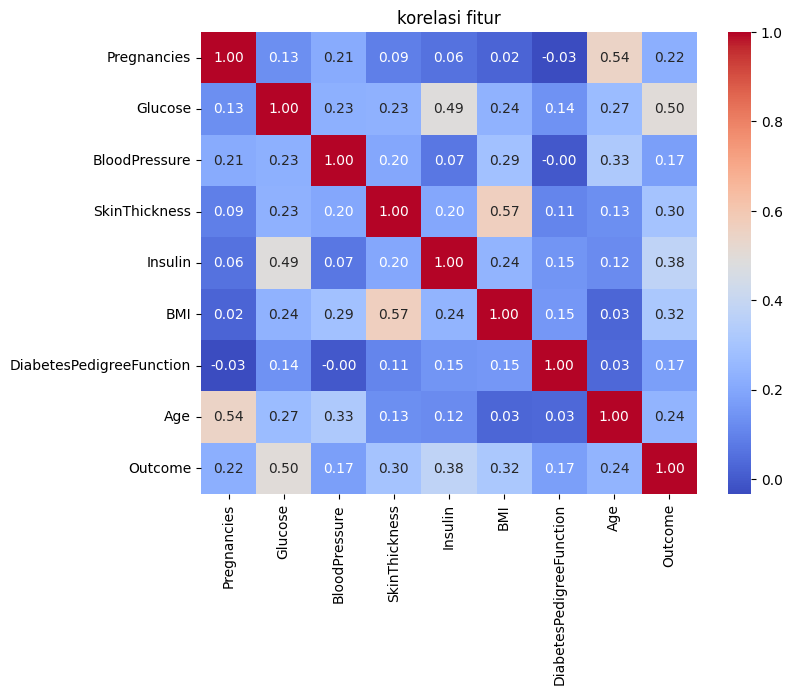

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

df = pd.read_csv('diabetes.csv')
display(df.head())

df.info()
print("\nstat deskriptif:\n", df.describe())
print("\nmissing val:\n", df.isnull().sum())

sns.countplot(data=df, x='Outcome', palette='Set2')
plt.title('distribusi Outcome target')
plt.show()

features = [c for c in df.columns if c != 'Outcome']
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, col in zip(axes.flatten(), features):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, ax=ax, palette='Set1')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('korelasi fitur')
plt.show()

In [2]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("jumlah val 0 tak wajar:\n", (df[zero_cols] == 0).sum())

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for col in zero_cols:
    med = X_tr[col].replace(0, np.nan).median()
    X_tr[col] = X_tr[col].replace(0, med)
    X_ts[col] = X_ts[col].replace(0, med)

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_ts_sc = scaler.transform(X_ts)

print("sc shape:", X_tr_sc.shape)

jumlah val 0 tak wajar:
 Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64
sc shape: (614, 8)


In [3]:
gnb = GaussianNB().fit(X_tr_sc, y_tr)
pred_gnb, prob_gnb = gnb.predict(X_ts_sc), gnb.predict_proba(X_ts_sc)[:, 1]

lr = LogisticRegression(random_state=42).fit(X_tr_sc, y_tr)
pred_lr, prob_lr = lr.predict(X_ts_sc), lr.predict_proba(X_ts_sc)[:, 1]

,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian NB,0.727273,0.603448,0.648148,0.625000
1,Logistic Regression,0.707792,0.588235,0.555556,0.571429


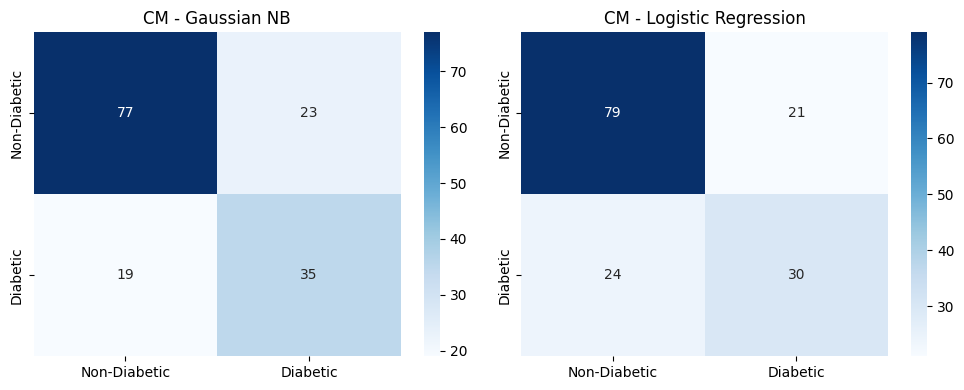

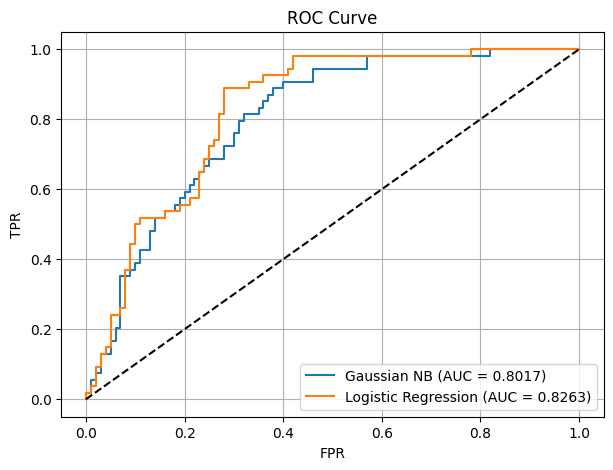

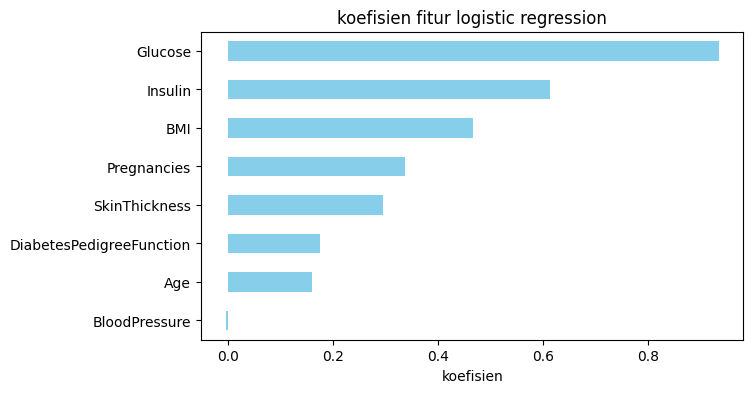

In [4]:
preds = [('Gaussian NB', pred_gnb), ('Logistic Regression', pred_lr)]
res = []
for name, p in preds:
    res.append({
        'Model': name,
        'Accuracy': accuracy_score(y_ts, p),
        'Precision': precision_score(y_ts, p),
        'Recall': recall_score(y_ts, p),
        'F1-Score': f1_score(y_ts, p)
    })
display(pd.DataFrame(res))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, p) in zip(axes, preds):
    sns.heatmap(confusion_matrix(y_ts, p), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Diabetic', 'Diabetic'], yticklabels=['Non-Diabetic', 'Diabetic'])
    ax.set_title(f'CM - {name}')
plt.tight_layout()
plt.show()

probs = [('Gaussian NB', prob_gnb), ('Logistic Regression', prob_lr)]
plt.figure(figsize=(7, 5))
for name, pr in probs:
    fpr, tpr, _ = roc_curve(y_ts, pr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend(); plt.grid(True)
plt.show()

coefs = pd.Series(lr.coef_[0], index=features).sort_values()
plt.figure(figsize=(7, 4))
coefs.plot(kind='barh', color='skyblue')
plt.title('koefisien fitur logistic regression')
plt.xlabel('koefisien')
plt.show()

imputasi median dilakukan berdasarkan data train untuk menghindari data leakage. kedua model mampu memprediksi diabetes dengan cukup baik pada fitur numerik terpilih. logistic regression cenderung memberikan kestabilan metrik dan interpretabilitas yang lebih oke lewat nilai koefisiennya, di mana fitur seperti glucose dan bmi memberikan pengaruh positif terbesar terhadap peningkatan risiko diabetes.

kesimpulan: gaussian naive bayes dan logistic regression terbukti efektif buat data numerik kontinu pima diabetes. penanganan nilai tidak wajar (0) serta penerapan standardscaler terbukti krusial menjaga kualitas performa model.

saran: bisa dicoba penanganan imbalanced class dengan teknik smote atau penyesuaian threshold/hyperparameter tuning (C pada logreg) untuk meningkatkan nilai recall pasien terindikasi diabetes.